In [7]:
import datetime
import pickle
import polars as pl
from donations import ml_utils
import mlflow
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error
from donations import constants
import numpy as np
import optuna
from optuna.integration.mlflow import MLflowCallback

In [8]:
with open("tmp/df_all.pkl", "rb") as file:
    df_all = pickle.load(file)

In [9]:
df_all = df_all.with_columns([
    pl.col("date").dt.weekday().alias("weekday"),
    pl.col("date").dt.month().alias("month"),
    pl.col("date").dt.ordinal_day().alias("day_of_year")   
])

df_all.head(8)

date,a,b,o,ab,all,is_religion_or_culture_holiday,is_other_holiday,is_low_donation_holiday,is_high_donation_holiday,weekday,month,day_of_year
date,i64,i64,i64,i64,i64,u8,u8,u8,u8,i8,i8,i16
2006-01-01,152,139,194,40,525,0,0,0,0,7,1,1
2006-01-02,53,43,112,19,227,0,0,0,0,1,1,2
2006-01-03,29,21,56,6,112,0,0,0,0,2,1,3
2006-01-04,92,98,165,36,391,0,0,0,0,3,1,4
2006-01-05,149,198,193,42,582,0,0,0,0,4,1,5
2006-01-06,94,77,126,27,324,0,0,0,0,5,1,6
2006-01-07,29,28,48,13,118,0,0,0,0,6,1,7
2006-01-08,218,212,314,51,795,0,0,0,0,7,1,8


In [10]:
for lag in range(1, constants.WINDOW_SIZE+1):
    df_all = df_all.with_columns(
        pl.col("all").shift(lag).alias(f"all_lag_{lag}")
    )

df_all = df_all.drop_nulls()

In [11]:
# Restricting data to 2019
df_all = df_all.filter(
    pl.col('date') >= datetime.date(2019, 1,1)
)

In [12]:
df_all

date,a,b,o,ab,all,is_religion_or_culture_holiday,is_other_holiday,is_low_donation_holiday,is_high_donation_holiday,weekday,month,day_of_year,all_lag_1,all_lag_2,all_lag_3,all_lag_4,all_lag_5,all_lag_6,all_lag_7
date,i64,i64,i64,i64,i64,u8,u8,u8,u8,i8,i8,i16,i64,i64,i64,i64,i64,i64,i64
2019-01-01,363,429,629,92,1513,0,0,0,0,2,1,1,857,1997,1465,893,1231,741,1135
2019-01-02,215,217,302,52,786,0,0,0,0,3,1,2,1513,857,1997,1465,893,1231,741
2019-01-03,358,408,581,94,1441,0,0,0,0,4,1,3,786,1513,857,1997,1465,893,1231
2019-01-04,205,223,334,42,804,0,0,0,0,5,1,4,1441,786,1513,857,1997,1465,893
2019-01-05,335,357,585,86,1363,0,0,0,0,6,1,5,804,1441,786,1513,857,1997,1465
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-20,448,488,783,62,1781,0,0,0,0,1,10,293,2190,1732,955,1594,1606,1391,924
2025-10-21,216,217,372,28,833,0,0,0,0,2,10,294,1781,2190,1732,955,1594,1606,1391
2025-10-22,397,380,663,79,1519,0,0,0,0,3,10,295,833,1781,2190,1732,955,1594,1606


In [13]:
X_seq = df_all.select([f"all_lag_{lag}" for lag in range(1, constants.WINDOW_SIZE+1)]).to_numpy().reshape(-1, constants.WINDOW_SIZE, 1)
X_features = df_all.select(["weekday", "month", "day_of_year", "is_religion_or_culture_holiday", "is_other_holiday", "is_low_donation_holiday", "is_high_donation_holiday"]).to_numpy()
y = df_all['all'].to_numpy()

In [14]:
# Set up scalers 
from sklearn.preprocessing import RobustScaler

y_scaler = RobustScaler()
X_scaler = RobustScaler()

In [15]:
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()
X_features_scaled = X_scaler.fit_transform(X_features)
X_seq_scaled = y_scaler.transform(X_seq.reshape(-1, 1)).reshape(-1, constants.WINDOW_SIZE, 1)

In [16]:
with open('shared/x_scaler.pkl', 'wb') as file:
    pickle.dump(X_scaler, file)
    
with open('shared/y_scaler.pkl', 'wb') as file:
    pickle.dump(y_scaler, file)

In [17]:
X_seq_train, X_seq_val, X_seq_test, X_features_train, X_features_val, X_features_test, y_train, y_val, y_test = ml_utils.train_val_test_split_feature_data(
    X_seq_scaled,
    X_features_scaled,
    y_scaled,
    constants.TRAIN_FRAC,
    constants.VAL_FRAC
)

In [18]:
experiment_name = f"{constants.EXPERIMENT_NAME}_{datetime.datetime.now().strftime('%Y%m%d')}"
experiment_id = ml_utils.get_or_create_mlflow_experiment(experiment_name)
mlflow.set_experiment(experiment_name)
mlflow_callback = MLflowCallback(
    tracking_uri = mlflow.get_tracking_uri(),
    metric_name = "val_loss"
)

In [19]:
def objective(trial):
    seq_type = trial.suggest_categorical("seq_type", ["LSTM", "SimpleRNN", "GRU"])
    seq_units = trial.suggest_int("seq_units", 12, 48)
    dense_units = trial.suggest_int("dense_units", 4, 12)
    activation = trial.suggest_categorical("activation", ["tanh", "relu", "mish"])
    optimizer = trial.suggest_categorical("optimizer", ["adam", "rmsprop"])
    dropout = trial.suggest_float("dropout", 0.05, 0.15, log=True)
    learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    
    ml_utils.run_experiment(
        X_seq_train, X_features_train, y_train,
        X_seq_val, X_features_val, y_val,
        seq_type=seq_type,
        seq_units=seq_units,
        dense_units=dense_units,
        activation=activation,
        optimizer=optimizer,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        experiment_id=experiment_id
    )
    
    runs = mlflow.search_runs(experiment_ids=[experiment_id], order_by=["start_time DESC"])
    val_loss = runs.iloc[0]["metrics.val_loss"]
    
    # Add pruning for unpromising trials
    trial.report(val_loss, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    print(f"Trial {trial.number + 1}/{constants.N_TRIALS} - Val Loss: {val_loss:.4f}")
    return val_loss

# Use TPE sampler with pruning
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

# Reduce number of trials
study.optimize(objective, n_trials=constants.N_TRIALS, callbacks=[mlflow_callback])

[I 2025-10-25 21:51:53,049] A new study created in memory with name: no-name-00688292-0b5c-475c-a203-944a12d626ba


[I 2025-10-25 21:52:25,669] Trial 0 finished with value: 0.7467865347862244 and parameters: {'seq_type': 'SimpleRNN', 'seq_units': 34, 'dense_units': 5, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.051143601096415, 'learning_rate': 0.08706020878304858, 'batch_size': 32}. Best is trial 0 with value: 0.7467865347862244.
2025/10/25 21:52:25 INFO mlflow.tracking.fluent: Experiment with name 'no-name-00688292-0b5c-475c-a203-944a12d626ba' does not exist. Creating a new experiment.


Validation Loss: 0.7467865347862244, Validation MAE: 0.6606445908546448
Trial 1/100 - Val Loss: 0.7468


[I 2025-10-25 21:53:06,040] Trial 1 finished with value: 0.2408125251531601 and parameters: {'seq_type': 'GRU', 'seq_units': 31, 'dense_units': 7, 'activation': 'relu', 'optimizer': 'rmsprop', 'dropout': 0.08252217908313293, 'learning_rate': 0.037183641805732096, 'batch_size': 64}. Best is trial 1 with value: 0.2408125251531601.


Validation Loss: 0.2408125102519989, Validation MAE: 0.35074037313461304
Trial 2/100 - Val Loss: 0.2408


...

[I 2025-10-26 09:08:48,251] Trial 98 finished with value: 0.21818490326404572 and parameters: {'seq_type': 'LSTM', 'seq_units': 15, 'dense_units': 9, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.06589807465271484, 'learning_rate': 0.0010727887185025236, 'batch_size': 32}. Best is trial 89 with value: 0.1949077546596527.


Trial 99/100 - Val Loss: 0.2182


Validation Loss: 0.20009873807430267, Validation MAE: 0.32104888558387756


[I 2025-10-26 09:10:49,279] Trial 99 finished with value: 0.20009873807430267 and parameters: {'seq_type': 'LSTM', 'seq_units': 14, 'dense_units': 9, 'activation': 'mish', 'optimizer': 'rmsprop', 'dropout': 0.058907178066155426, 'learning_rate': 0.0015250726128634357, 'batch_size': 32}. Best is trial 89 with value: 0.1949077546596527.


Trial 100/100 - Val Loss: 0.2001


In [20]:
model = ml_utils.get_best_model(experiment_id, "metrics.val_loss")
y_pred = y_scaler.inverse_transform(model.predict([X_seq_test, X_features_test]))
y_test_scaled = y_scaler.inverse_transform(y_test.reshape(-1, 1))
mean_absolute_error(y_test_scaled, y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


198.7208726671007

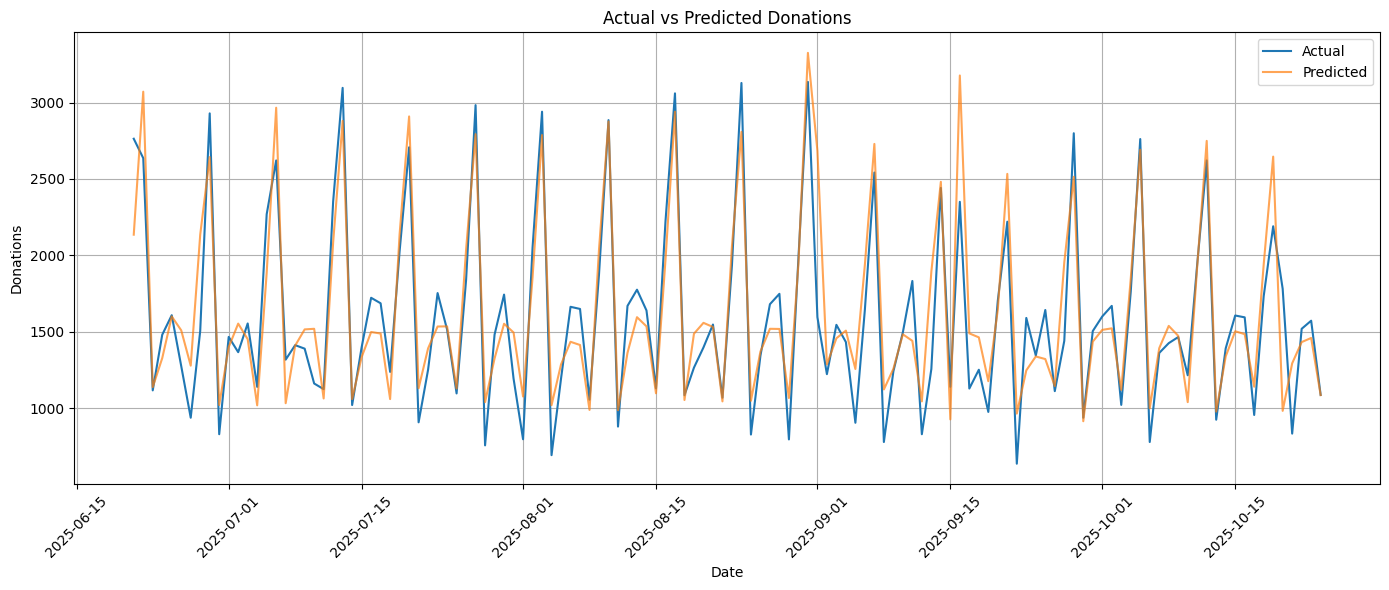

In [21]:
pred_df = pl.DataFrame({'y_true': y_test_scaled.flatten(), 'y_pred': np.round(y_pred).flatten()})

pred_df = pred_df.with_columns(
    (pl.col('y_true') - pl.col('y_pred')).alias('diff')
).with_columns(
    pl.Series("date", df_all[-pred_df.height:]["date"])
)

pred_df = pred_df.with_columns(
    (abs(pl.col('diff')).alias('abs_diff'))
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(pred_df["date"], pred_df["y_true"], label="Actual")
plt.plot(pred_df["date"], pred_df["y_pred"], label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted Donations")
plt.xlabel("Date")
plt.ylabel("Donations")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
pred_df['y_true'].mean()

1595.968253968254

In [23]:
pred_df.sort(by='abs_diff', descending=True).head(10)

y_true,y_pred,diff,date,abs_diff
f64,f32,f64,date,f64
1595.0,2684.0,-1089.0,2025-09-01,1089.0
2350.0,3177.0,-827.0,2025-09-16,827.0
1781.0,982.0,799.0,2025-10-20,799.0
1256.0,1893.0,-637.0,2025-09-13,637.0
1505.0,2135.0,-630.0,2025-06-28,630.0
2763.0,2135.0,628.0,2025-06-21,628.0
1440.0,1954.0,-514.0,2025-09-27,514.0
833.0,1293.0,-460.0,2025-10-21,460.0
2190.0,2646.0,-456.0,2025-10-19,456.0


While all in all the model seems to be performing well, on certain days it still shows a bigger deviance:
- 2025-09-01: Merdeka Day Holiday (additional holiday given this year)
- 2025-09-16: Malaysia Day (all states)
- 2025-10-20: Deepvali

Other than that, the month of June in general shows greater deviations.

In [24]:
# Saving the model
model.save(f"shared/model_{experiment_name}.keras")

## Comparison with simple benchmarks

### Comparison with mean value from the validation set

In [26]:
# Comparison with mean value from validation set
mean_val = y_scaler.inverse_transform(y_val.reshape(-1, 1)).mean()

mean_pred = np.full_like(y_test_scaled, mean_val)
mean_absolute_error(y_test_scaled, mean_pred)

476.2190220174091

### Comparison with rolling average

In [27]:
# Concatenate y_train, y_val, and y_test for easy indexing
y_all = np.concatenate([y_val, y_test])

# Indices for the start of y_test in y_all
test_start_idx = len(y_val)

# Rolling average prediction for y_test
rolling_preds = []
for i in range(test_start_idx, test_start_idx + len(y_test)):
    # Take the previous 7 days
    prev_7 = y_all[i-constants.WINDOW_SIZE:i]
    rolling_preds.append(prev_7.mean())

rolling_preds = np.array(rolling_preds)

mean_absolute_error(y_test, 
                    y_scaler.inverse_transform(rolling_preds[-len(y_test):].reshape(-1, 1))
)

1602.2446573302643

We could confirm that using the model is meaningfully better in terms of performance over simple benchmarks.